In [1]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time
sys.path.append('/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *

import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0


print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [2]:
%%time

fpath =OrderedDict()
tree = OrderedDict()

start_t = time.time()
version = 'v30'
LUMI_SCALE = 1
# for data_year in ['2022','2023','all']:
for data_year in ['all']:

    # path = "/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/data/raw/"
    # fpath_bkg[data_year] = path + f"data_{data_year}_goodLumi.root"
    if data_year == 'all':path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/{version}/normalized/'
    else: path = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data{data_year}/{version}/normalized/'
    if data_year == '2022':fpath['data'+data_year] = path + "DisplacedJet-EXOCSCCluster_Run2022-PromptReco.root"
    elif data_year == '2023':fpath['data'+data_year] = path + "Muon-EXOCSCCluster_Run2023-PromptReco_goodLumi.root"
    elif data_year == 'all':fpath['data'+data_year] = path + "EXOCSCCluster_Run2022_2024_goodLumi.root"

fpath['sig'] = f'/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root'
NEvents = {}

for k,v in fpath.items():
    print (k, v)
    root_dir = uproot.open(v) 

    tree[k] = root_dir['MuonSystem']
    NEvents[k] = root_dir['NEvents'].values()[0]
    # NEvents[k] = root_dir['NEvents'].counts()
    print("NEvents",NEvents[k])


dataall /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19//Data_all/v30/normalized/EXOCSCCluster_Run2022_2024_goodLumi.root
NEvents 182909920.0
sig /storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/v30/normalized/ggH_Hto2Sto4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_160000pb_weighted.root
NEvents 189549180.0
CPU times: user 453 ms, sys: 12.8 ms, total: 466 ms
Wall time: 473 ms


In [3]:
# NEvents 159888100.0
categories = ['inclusive']


In [4]:
# categories = ['NStation3', 'NStation4']
categories = ['inclusive']
categories = ['lowMET', 'highMET']
region_list = ['oot', 'signal', 'invertDNN']
MET_THRESHOLD = 30

# apply selections

In [5]:
%%time


JET_PT_CUT = 30
MUON_PT_CUT = 30.0

cscRechitClusterPhi0 = {}
cscRechitClusterPhi1 = {}
deltaPhi_cluster  = {}
cscRechitClusterDNN0  = {}
cscRechitClusterDNN1  = {}
cscRechitClusterTime0  = {}
cscRechitClusterTime1  = {}
cscRechitClusterSize0  = {}
cscRechitClusterSize1  = {}
deltaR_cluster = {}
cscRechitClusterNStation = {}
cscRechitClusterEta = {}
cscRechitClusterPhi = {}
runNum = {}
HMTEff = {}
weight = {}
nJets = {}
jetPt = {}
Puppimet= {}
met = {}
for region in region_list:
    for tree_k in tree.keys():
        T = tree[tree_k]
        for cat in categories:
            # if not region == 'signal': continue
            k = f'{region}_{tree_k}_{cat}'

        ########### SELECTION: JETS ############

            sel_jet = np.abs(T['jetEta'].array())<2.4
        ########### SELECTION: CLUSTERS ############
            me1 = (T['cscRechitClusterNRechitChamberPlus11'].array()+ T['cscRechitClusterNRechitChamberPlus12'].array()+\
            T['cscRechitClusterNRechitChamberMinus11'].array()+ T['cscRechitClusterNRechitChamberMinus12'].array())

            # cluster = 
            #one cluster to pass trigger
            # cluster0 = np.logical_and(T['cscRechitClusterTimeWeighted'].array() < 12.5, T['cscRechitClusterTimeWeighted'].array() > -5)
            cluster =  (me1 ==0)
            # cluster = (T['cscRechitClusterTimeSpreadWeightedAll'].array()<20)
            cluster = cluster & (T['cscRechitClusterJetVetoPt'].array() < JET_PT_CUT)
            cluster = cluster & np.logical_not((T['cscRechitClusterMuonVetoPt'].array() > MUON_PT_CUT) & T['cscRechitClusterMuonVetoGlobal'].array())    

        ########### SELECTION: EVENTS ############
            sel_ev = T['HLT_CSCCSC'].array()
            # sel_ev  = np.logical_and(sel_ev,np.sum(cluster0, axis = 1) >= 1)
            sel_ev  = np.logical_and(sel_ev,np.sum(cluster, axis = 1) == 2)

            cluster_pass_HLT = HLT_CSC(T['cscRechitClusterEta'].array(),T['cscRechitClusterNStation10'].array(),T['cscRechitClusterSize'].array())
            sel_ev  = np.logical_and(sel_ev,np.sum(cluster_pass_HLT, axis = 1) >= 1) # at least one passes HLT
            sel_ev = sel_ev & (np.sum(T['cscRechitClusterNStation10'].array(),axis=1) > 2)
            if cat == 'NStation3':sel_ev = sel_ev & (np.sum(T['cscRechitClusterNStation10'].array(),axis=1) == 3)
            elif cat == 'NStation4':sel_ev = sel_ev & (np.sum(T['cscRechitClusterNStation10'].array(),axis=1) >= 4)
            sel_ev = np.logical_and(sel_ev ,T['nCscRings'].array()+T['nDtRings'].array()<10)
            sel_ev = np.logical_and(sel_ev ,T['jetVeto'].array())
            sel_ev = np.logical_and(sel_ev ,T['Flag_ecalBadCalibFilter'].array())
            
            if cat == 'lowMET':sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < MET_THRESHOLD)
            elif cat == 'highMET': 
                sel_ev = sel_ev & (T['Puppimet'].array() > MET_THRESHOLD) 
            sel_ev = np.logical_and(sel_ev ,T['Puppimet'].array() < 200)
            sel_ev = np.logical_and(sel_ev ,T['Flag_all'].array())
            sel_ev = np.logical_and(sel_ev,T['nCscRechitClusters_nocut'].array()==2)

        ########### BRANCHES ############
           ##### event variables ##### 

            cscRechitClusterPhi0[k] = T['cscRechitClusterPhi'].array()[cluster][sel_ev][:,0]
            cscRechitClusterPhi1[k] = T['cscRechitClusterPhi'].array()[cluster][sel_ev][:,1]
            deltaPhi_cluster[k] = deltaPhi(np.array(cscRechitClusterPhi0[k]), np.array(cscRechitClusterPhi1[k]))

            cscRechitClusterDNN0[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[cluster][sel_ev][:,0]
            cscRechitClusterDNN1[k] = T['cscRechitClusterDNN_bkgMC_plusBeamHalo'].array()[cluster][sel_ev][:,1]
            cscRechitClusterTime0[k] = T['cscRechitClusterTimeWeighted'].array()[cluster][sel_ev][:,0]
            cscRechitClusterTime1[k] = T['cscRechitClusterTimeWeighted'].array()[cluster][sel_ev][:,1]
            cscRechitClusterSize0[k] = T['cscRechitClusterSize'].array()[cluster][sel_ev][:,0]
            cscRechitClusterSize1[k] = T['cscRechitClusterSize'].array()[cluster][sel_ev][:,1]
            cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[cluster][sel_ev]
            deltaR_cluster[k] = ((cscRechitClusterEta[k][:,0]-cscRechitClusterEta[k][:,1])**2 + deltaPhi_cluster[k]**2)**0.5
            cscRechitClusterNStation[k] = np.sum(T['cscRechitClusterNStation10'].array()[cluster][sel_ev], axis=1)
                # 
            # sel = (np.abs(deltaPhi_cluster[k])>1.8) & (deltaR_cluster[k] < 3.5) 
            if cat == 'lowMET': sel = (np.abs(deltaPhi_cluster[k])>1.8) & (deltaR_cluster[k] < 3.5) 
            elif cat == 'highMET': sel = (np.abs(deltaPhi_cluster[k])>0.4) & (deltaR_cluster[k] < 3.5)
            else: sel = (np.abs(deltaPhi_cluster[k])>0.4) & (deltaR_cluster[k] < 3.5)
            sel = sel & (cscRechitClusterDNN0[k] > 0.96) & (cscRechitClusterTime0[k]>-5) & (cscRechitClusterTime0[k]<12.5)
            sel = sel & (np.abs(cscRechitClusterEta[k][:,0])<1.9) & (np.abs(cscRechitClusterEta[k][:,1])<1.9)
            if 'oot' in region:
                sel = sel & (cscRechitClusterDNN1[k] > 0.96) & (cscRechitClusterTime1[k]<-12.5)
            elif 'invertDNN' in region:
                sel = sel & (cscRechitClusterDNN1[k] < 0.96) & (cscRechitClusterDNN1[k] > 0.9) & (cscRechitClusterTime1[k]>-5) & (cscRechitClusterTime1[k]<12.5)
            elif 'signal' in region:
                sel = sel & (cscRechitClusterDNN1[k] > 0.96) & (cscRechitClusterTime1[k]>-5) & (cscRechitClusterTime1[k]<12.5)
            else: assert(False)
            deltaPhi_cluster[k] = deltaPhi_cluster[k][sel]
            cscRechitClusterSize1[k] = cscRechitClusterSize1[k][sel]
            HMTEff[k] = T['cscRechitClusterHMTEfficiency'].array()[sel_ev][sel]

            cluster_pass_HLT = cluster_pass_HLT[sel_ev][sel]
            HMTEff[k] = 1-HMTEff[k][cluster_pass_HLT]
            HMTEff[k] = 1-np.prod(HMTEff[k],axis=1)

            cscRechitClusterEta[k] = T['cscRechitClusterEta'].array()[cluster][sel_ev][sel]
            cscRechitClusterPhi[k] = T['cscRechitClusterPhi'].array()[cluster][sel_ev][sel]
            runNum[k] = T['runNum'].array()[sel_ev][sel]
            nJets[k] = T['nJets'].array()[sel_ev][sel]
            met[k] = T['met'].array()[sel_ev][sel]
            Puppimet[k] = T['Puppimet'].array()[sel_ev][sel]

            if 'data' in k:weight[k] = (T['weight'].array())[sel_ev][sel]*0.0 + 1                                                             
            else: weight[k] = (T['pileupWeight'].array()*T['weight'].array())[sel_ev][sel]*HMTEff[k]*LUMI_SCALE
            print("events in this region:", k, len(deltaPhi_cluster[k]), np.sum(weight[k]), len(weight[k]))

events in this region: oot_dataall_lowMET 237 237.0 237
events in this region: oot_dataall_highMET 345 345.0 345
events in this region: oot_sig_lowMET 0 0.0 0
events in this region: oot_sig_highMET 2 3.2432296 2
events in this region: signal_dataall_lowMET 136 136.0 136
events in this region: signal_dataall_highMET 268 268.0 268
events in this region: signal_sig_lowMET 1668 1931.7477 1668
events in this region: signal_sig_highMET 2301 2614.0637 2301
events in this region: invertDNN_dataall_lowMET 55 55.0 55
events in this region: invertDNN_dataall_highMET 134 134.0 134
events in this region: invertDNN_sig_lowMET 211 242.89836 211
events in this region: invertDNN_sig_highMET 288 318.04718 288
CPU times: user 1min 6s, sys: 7.46 s, total: 1min 13s
Wall time: 1min 14s


<Array [[1.29, 1.4], ... [1.37, 1.49]] type='311 * var * float32'>

# check inverted DNN region

0.0037195682525634766


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


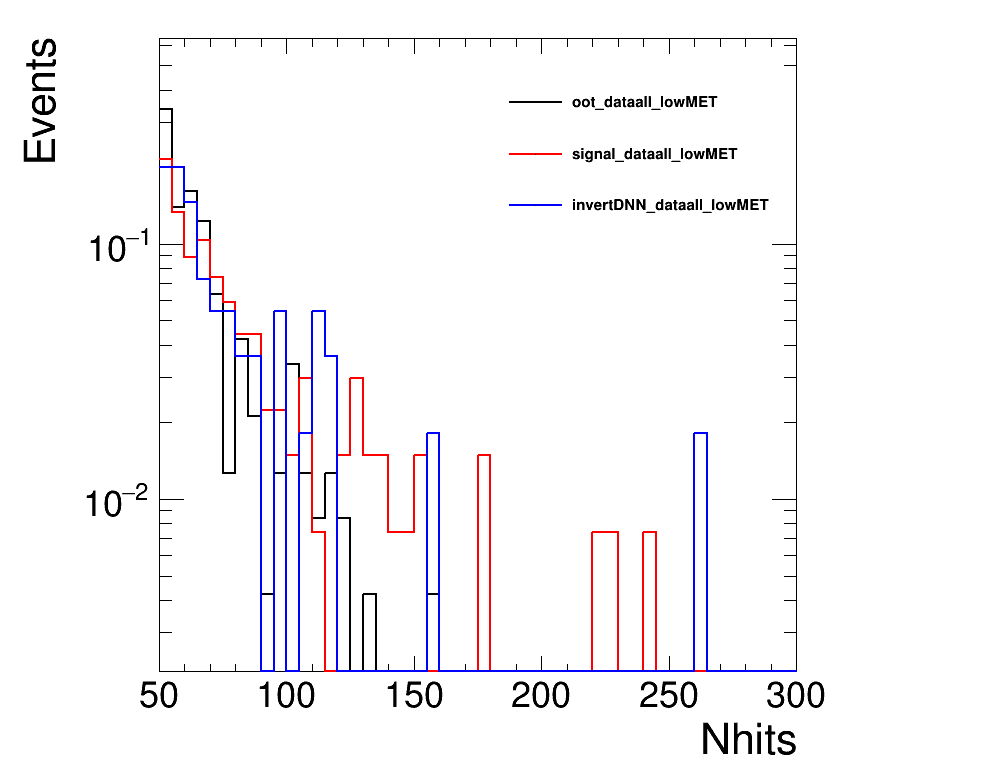

In [19]:
# Plotting ncsc
start_t = time.time()
c = rt.TCanvas('c','c', 1000, 800)
h = {}
leg = rt.TLegend(0.5,0.7,0.8,0.9)
leg.SetBorderSize(0)
# plot_var = [cscRechitClusterSize1, deltaPhi_cluster]
# axis = ['N_{rechits}','#Delta#phi',]
# name = ['nhits','dphi']
# bins = [[25,50,500],[25,1.8,3.2]]


k = "oot_dataall_inclusive"
# h = create_TH2D(np.column_stack(( np.array(cscRechitClusterEta[k][:,1]), np.array(cscRechitClusterPhi[k][:,1]))),\
#                axis_title = ['#eta','#phi','Events'], binning=[100,-3,3,100,-3.2,3.2])

# h = create_TH2D(np.column_stack(( np.array(met[k]), np.array(Puppimet[k]))),\
#                axis_title = ['met','puppi met','Events'], binning=[100,0,500,100,0,500])
# h.Draw('colz')
i = 0
for k in met.keys():
    if "oot_sig" in k:continue
    if not "lowMET" in k:continue
    if "_sig_" in k:continue
    # h[k] = create_TH1D(np.array(met[k]-Puppimet[k]),  axis_title = ['met-puppi met','Events'], binning=[100,-100,150])
    # h[k] = create_TH1D(np.array(Puppimet[k]),  axis_title = ['puppi met','Events'], binning=[100,0,300])
    # h[k] = create_TH1D(np.array(met[k]),  axis_title = [' met','Events'], binning=[100,0,300])
    h[k] = create_TH1D(np.array(cscRechitClusterSize1[k]),  axis_title = ['Nhits','Events'], binning=[50,50,300])
    h[k].SetLineColor(std_color_list[i])
    leg.AddEntry(h[k],k)
    h[k].DrawNormalized("same hist")
    i+=1

# print(np.min(runNum[k]),np.max(runNum[k]))
# h = create_TH1D( np.array(runNum[k]), axis_title = ['run number','Events'], binning=[5000,360000,371000])
# h.Draw()
# h[k].SetLineColor(std_color_list[i])
# leg.AddEntry(h[k],k.replace('all',''))
leg.Draw()
c.SetRightMargin(0.2)
c.SetLogy()
c.Draw()

# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".png")
# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".pdf")
# c.SaveAs("/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/ABCD/"+name[plot_index]+".C")




print(time.time()-start_t)

In [42]:
MET_THRESHOLD

50

## Create datacard with OOT data for optimization

In [7]:
# if MET_THRESHOLD == 50: datacard_version = 'v23'
# elif MET_THRESHOLD == 100:datacard_version = 'v24'
# elif MET_THRESHOLD == 75:datacard_version = 'v25'

# if MET_THRESHOLD == 50: datacard_version = 'v27'
datacard_version = 'v33'
print(datacard_version)
outDataCardsDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/csccsc/OOT_opt/{datacard_version}/"
tree_dir = outDataCardsDir.replace("datacards","limitTrees")

v33


In [16]:
for cat in categories:
    data_key = f'oot_dataall_{cat}'
    signal_key = f'signal_sig_{cat}'
    a, b, c, d, pred = {}, {}, {}, {}, {}

    outDataCardsDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/csccsc/OOT_opt/{datacard_version}/"
    tree_dir = outDataCardsDir.replace("datacards","limitTrees")
    os.system(f"mkdir -p {outDataCardsDir}")
    os.system(f"mkdir -p {tree_dir}")
    modelName="ggH_HToSSTobbbb_MH-125_MS-15_CTau1000"

    sig_unc = {'ggH':[[0.2]*4]}
    sig_unc_name = ['test']
    signal_region = 'a'
    prefix = f'csccsc_{cat}_'
    h = {
    signal_key: rt.TH2D("","",22,80,300, 14,1.8,3.2),
    data_key: rt.TH2D("","",22,80,300, 14,1.8,3.2),
    }
    print("TF", len(cscRechitClusterSize1[f'signal_dataall_{cat}'])/len(cscRechitClusterSize1[data_key]))
    for nhit_cut in np.arange(80,300,10):
        if not nhit_cut == 180:continue
        for dphi_cut in np.round(np.arange(0.5, 3.2, 0.1),1):
            if not dphi_cut == 2.8:continue
            
            k = signal_key
            TF = len(cscRechitClusterSize1[f'signal_dataall_{cat}'])/len(cscRechitClusterSize1[data_key])
            
            for k in [data_key, signal_key]:
                if k == data_key: 
                    TF = len(cscRechitClusterSize1[f'signal_dataall_{cat}'])/len(cscRechitClusterSize1[data_key])
                else: TF = 1
                a[k] = np.sum(weight[k][(cscRechitClusterSize1[k]>=nhit_cut) &  (np.abs(deltaPhi_cluster[k])>=dphi_cut)]) * TF
                b[k] = np.sum(weight[k][(cscRechitClusterSize1[k]>=nhit_cut) &  (np.abs(deltaPhi_cluster[k])<dphi_cut)]) * TF
                c[k] = np.sum(weight[k][(cscRechitClusterSize1[k]<nhit_cut) &  (np.abs(deltaPhi_cluster[k])<dphi_cut)]) * TF
                d[k] = np.sum(weight[k][(cscRechitClusterSize1[k]<nhit_cut) &  (np.abs(deltaPhi_cluster[k])>=dphi_cut)]) * TF
                if c[k] == 0: pred[k] = 999
                else: pred[k] = b[k]*d[k]/c[k]

                if k == data_key:
                    if b[k]/TF < 1 or c[k]/TF < 1 or d[k]/TF < 1:continue
                    unc_pred = (TF/c[k] + TF/b[k] + TF/d[k])**0.5*pred[k]
                
            # print(cat, dphi_cut, b[f'oot_dataall_{cat}'], c[f'oot_dataall_{cat}'], d[f'oot_dataall_{cat}'])
            if b[data_key] < 0.1 or c[data_key] < 0.1 or d[data_key] < 0.1:continue
            # print(nhit_cut, dphi_cut, a[signal_key], pred[data_key], a[signal_key]/pred[data_key], unc_pred, pred[data_key])
            print(cat, dphi_cut, pred[data_key], b[data_key], c[data_key], d[data_key], TF)


            xbin = h[data_key].GetXaxis().FindBin(nhit_cut)
            ybin = h[data_key].GetYaxis().FindBin(dphi_cut)
            h[data_key].SetBinContent(xbin,ybin,pred[data_key])
            h[signal_key].SetBinContent(xbin,ybin,a[signal_key])

            card_name = f'nhits{nhit_cut}_dphi'+str(round(dphi_cut,1)).replace(".","p") + f'_{cat}'
            ## create datacards ##
            # make_datacard_2tag(
            # outDataCardsDir,
            # card_name,
            # {'ggH':[a[signal_key],b[signal_key],c[signal_key],d[signal_key]]}, #signal rate
            # a[signal_key], 
            # [pred[data_key],b[data_key],c[data_key],d[data_key]], #bkg rate
            # [pred[data_key],b[data_key],c[data_key],d[data_key]], #observation
            # [unc_pred/pred[data_key],0,0,0], 
            # ['syst'], 
            # sig_unc, 
            # sig_unc_name,
            # signal_region, 
            # prefix
            # )




TF 0.5738396624472574
TF 0.7768115942028986
highMET 2.8 0.07421766823594574 0.7768115942028986 243.91884057971015 23.304347826086957 1


In [17]:
TF 1.0
lowMET 2.8 0.8888888888888888 4.0 108.0 24.0 1
TF 1.0
highMET 2.8 1.235042735042735 17.0 234.0 17.0 1

{'oot_dataall_lowMET': <Array [56, 66, 71, 54, 52, ... 50, 67, 50, 69] type='237 * int32'>,
 'oot_dataall_highMET': <Array [78, 60, 100, 50, ... 90, 61, 86, 93] type='345 * int32'>,
 'oot_sig_lowMET': <Array [] type='0 * int32'>,
 'oot_sig_highMET': <Array [61, 54] type='2 * int32'>,
 'signal_dataall_lowMET': <Array [67, 70, 74, 52, ... 55, 53, 66, 61] type='136 * int32'>,
 'signal_dataall_highMET': <Array [73, 72, 100, 103, ... 70, 157, 61, 193] type='268 * int32'>,
 'signal_sig_lowMET': <Array [384, 108, 159, 79, ... 93, 237, 97] type='1668 * int32'>,
 'signal_sig_highMET': <Array [68, 117, 193, 147, ... 86, 327, 217] type='2301 * int32'>,
 'invertDNN_dataall_lowMET': <Array [118, 56, 158, 80, ... 52, 75, 66, 54] type='55 * int32'>,
 'invertDNN_dataall_highMET': <Array [105, 64, 69, 95, ... 52, 53, 68, 99] type='134 * int32'>,
 'invertDNN_sig_lowMET': <Array [120, 57, 60, 57, ... 159, 101, 344] type='211 * int32'>,
 'invertDNN_sig_highMET': <Array [262, 81, 56, 137, ... 148, 161, 118

# plot signal/bkg

signal_sig_highMET


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


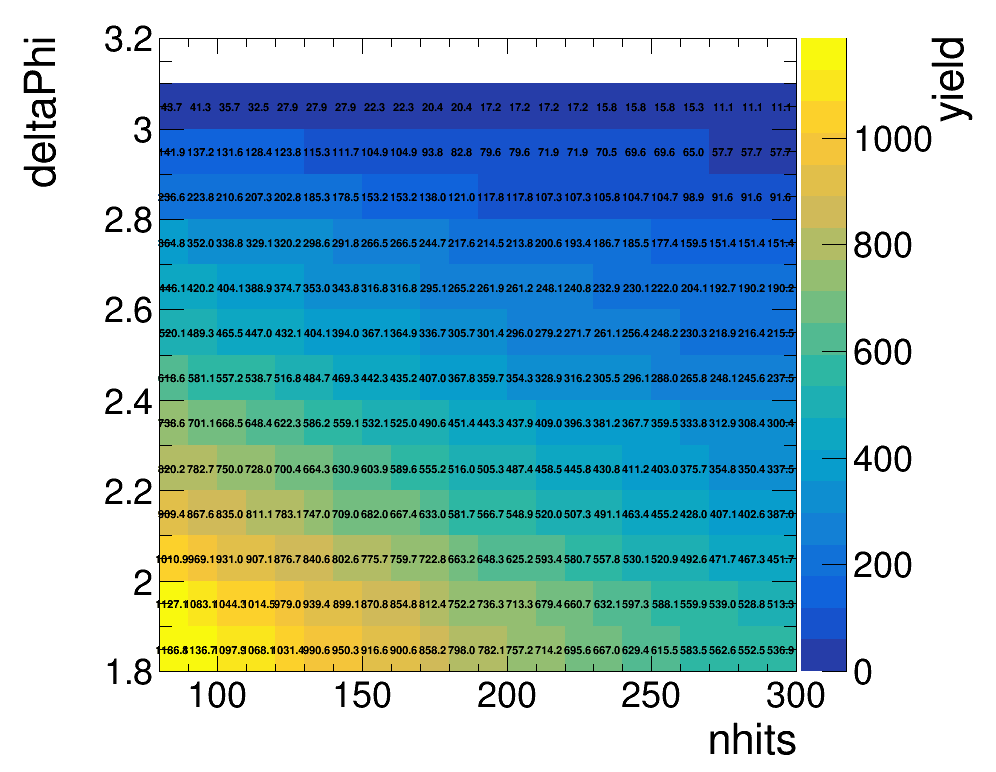

In [36]:
rt.gStyle.SetPaintTextFormat("1.1f");
c = rt.TCanvas('c','c', 1000, 800)

k = signal_key
# k = 'invertDNN_dataall_lowMET'
print(k)
h[k].GetXaxis().SetTitle("nhits")
h[k].GetYaxis().SetTitle("deltaPhi")
h[k].GetZaxis().SetTitle("yield")
h[k].GetZaxis().SetTitleOffset(1.1)
h[k].SetMarkerSize(0.8)

h[k].Draw("colz text")
c.SetRightMargin(0.2)
c.Draw()

## Plot combine result

In [38]:
datacard_version = 'v35'
outDataCardsDir=f"/storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_1_0_pre4/src/HiggsAnalysis/MuonSystemLimit/combine/datacards_run3HMT/csccsc/OOT_opt/{datacard_version}/"
tree_dir = outDataCardsDir.replace("datacards","limitTrees")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file v35_lowMET.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file v35_highMET.png has been created


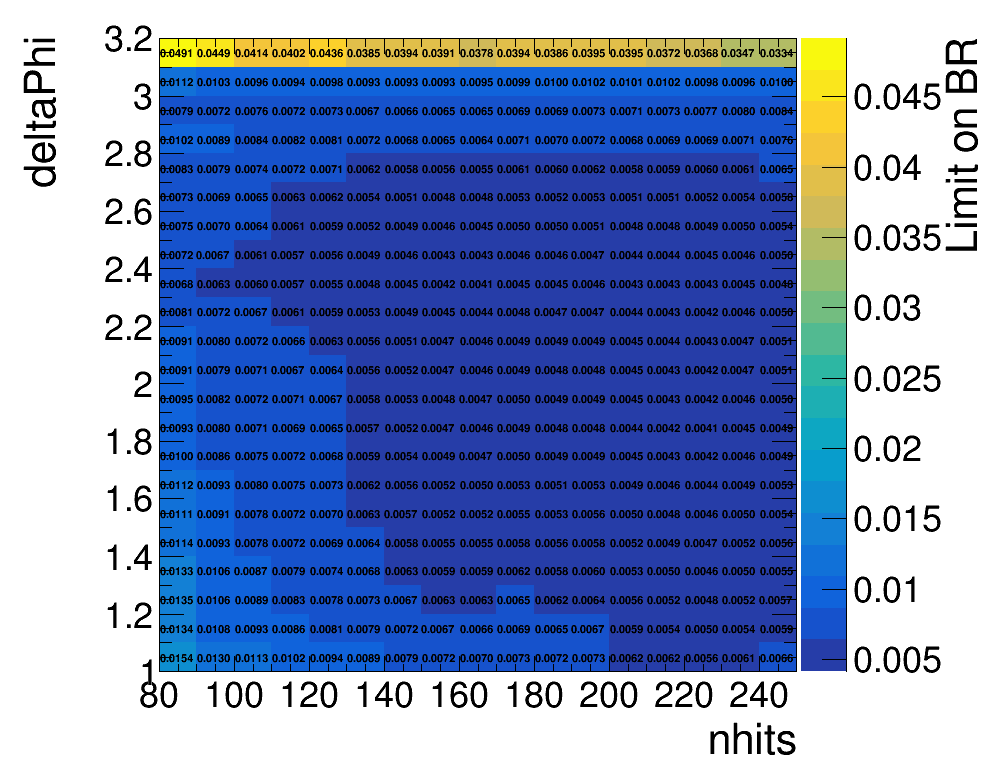

In [39]:
rt.gStyle.SetPaintTextFormat("1.4f");


for cat in categories:
    c = rt.TCanvas('c','c', 1000, 800)
    h_opt = rt.TH2D("","",20,100,300, 14,1.8,3.2)
    h_opt = rt.TH2D("","",17,80,250, 22,1.,3.2)
    for nhit_cut in np.arange(80,300,10):
        for dphi_cut in np.arange(1, 3.2, 0.1):

            ###### open datacard and limit ######
            card_name = f"nhits{nhit_cut}_dphi"+str(round(dphi_cut,1)).replace(".","p") + f'_{cat}'
            if not os.path.isfile(f"{outDataCardsDir}/{card_name}.txt"):continue
            # print(f"{outDataCardsDir}/{card_name}.txt")
            

            tree_name = f"higgsCombine.{card_name}.AsymptoticLimits.mH120.root"
            limitTree = tree_dir + '/' + tree_name
            if not os.path.isfile(limitTree):continue
            
            signal_norm = readNorm(f"{outDataCardsDir}/{card_name}.txt")
            if len(uproot.open(limitTree).keys()) == 2:
                    T = uproot.open(limitTree)['limit']                
                    if len(np.array(T['limit'].array())>0):limit = np.array(T['limit'].array())/signal_norm

            xbin = h_opt.GetXaxis().FindBin(nhit_cut)
            ybin = h_opt.GetYaxis().FindBin(dphi_cut)
            h_opt.SetBinContent(xbin,ybin,limit[2])
            # if limit[2]<0.008: print(nhit_cut, dphi_cut, limit[2], h[data_key].GetBinContent(xbin,ybin), h[signal_key].GetBinContent(xbin,ybin))

    h_opt.SetMarkerSize(0.8)
    h_opt.GetXaxis().SetTitle("nhits")
    h_opt.GetYaxis().SetTitle("deltaPhi")
    h_opt.GetZaxis().SetTitle("Limit on BR")
    h_opt.GetZaxis().SetTitleOffset(1.2)
    h_opt.Draw("colz text")
    c.SetRightMargin(0.2)
    c.Draw()
    c.SaveAs(f"{datacard_version}_{cat}.png")

In [31]:
v22 (wrong version)
combined is 0.0014 --> 0.0015

low MET: 0.0021
highMET: 0.0024
v23
low MET: 0.0018, same point
highMET: 0.003, 170,2.1
    
v25: 
    low MET0.0019, 160, 2.8
    high: 0.006
    
v24: 
    low MET0.0019, 160, 2.8

SyntaxError: invalid syntax (<ipython-input-31-285cf534e46c>, line 3)

In [ ]:
low MET: 160, 2.8
high MET 170, 2.1